<a href="https://colab.research.google.com/github/hadiritch-cell/Strogatz/blob/main/HumanBrainConnectome-N1292442.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MATH34041/44041: Network Analysis of the Human Brain Connectome
  **Name:** Richard Adom-Offe
  **Student ID:** N1292442
  **Email:** richard.adom-offe2025@my.ntu.ac.uk

# Coursework Assessment and Specification

**Module Code**: MATH34041/44041\
**Module Title**: Topics in Mathematical Biology\
**Assessor**: Dr Jonathan Crofts\
**Moderator**: Dr Martin Nelson\
**Learning Outcomes Assessed**: MLO1, MLO4, MLO5, MLO6, MLO7, MLO10, MLO11\
**Contribution to Element**: 100% of Element 2 (50% of the module)\
**Date Set**: 01/04/2026\
**Date of Submission**: 01/05/2026\
**Method**: Dropbox and TurnitIn\
**Feedback Method**: Personal comments via email\
**Note**: The usual University penalties apply for late submission and plagiarism. Please consult your student handbook for further details.\
**NEC**: https://www.ntu.ac.uk/studenthub/my-course/student-handbook/submit-a-notification-of-extenuating-circumstances \
**Writing**: https://librarybookings.ntu.ac.uk/

---
# Assessment Requirements

This coursework counts for 50% of your module. You can achieve a maximum of 100 marks.

<strong>You should complete this work in Python and write a report as a Colab notebook. Therefore, your submission should include a report, executable Python code and its output, as well as any data used to produce the output. </strong>

In particular, note the following guidance for laying out your coursework:

  - Lines that start with a hash (#) are Python comments; you can use these to add notes or explanations within your work.
  - Follow the layout of the example sheet solutions and codes given in the lecture notes.
  - It is important to produce high quality plots. Make sure they have readable axes and labels. Number them in order of appearance. Provide explanatory captions.
---
# Assessment Problems



## Task 1: Small-World Networks [35 marks]

Load a data file describing the connectivity structure of a biological process of your choice and create a *NetworkX* graph object. (See my [github pages](https://github.com/jjcrofts77/TMB-MATH34041/tree/1a626fd98efdd58c0bb69b6612dcd58d32583994/content/Data) for some examples.)
  


   0   1   2   3   4   5   6   7   8   9   ...  72  73  74  75  76  77  78  \
0   0   0   0   0   0   0   1   0   0   1  ...   0   0   0   0   0   0   0   
1   0   0   0   0   1   0   0   0   1   0  ...   0   0   0   0   0   0   0   
2   0   0   0   0   0   0   0   1   0   0  ...   0   0   0   0   0   0   0   
3   0   0   0   0   1   0   0   1   1   1  ...   0   0   0   0   0   0   0   
4   0   1   0   1   0   1   0   0   1   1  ...   0   0   0   1   0   0   0   

   79  80  81  
0   0   0   0  
1   0   0   0  
2   0   0   0  
3   1   0   0  
4   0   0   0  

[5 rows x 82 columns]
(82, 82)

Graph type:    Graph
Nodes:         82
Edges:         1089
Is directed?   False
Avg degree:    26.56


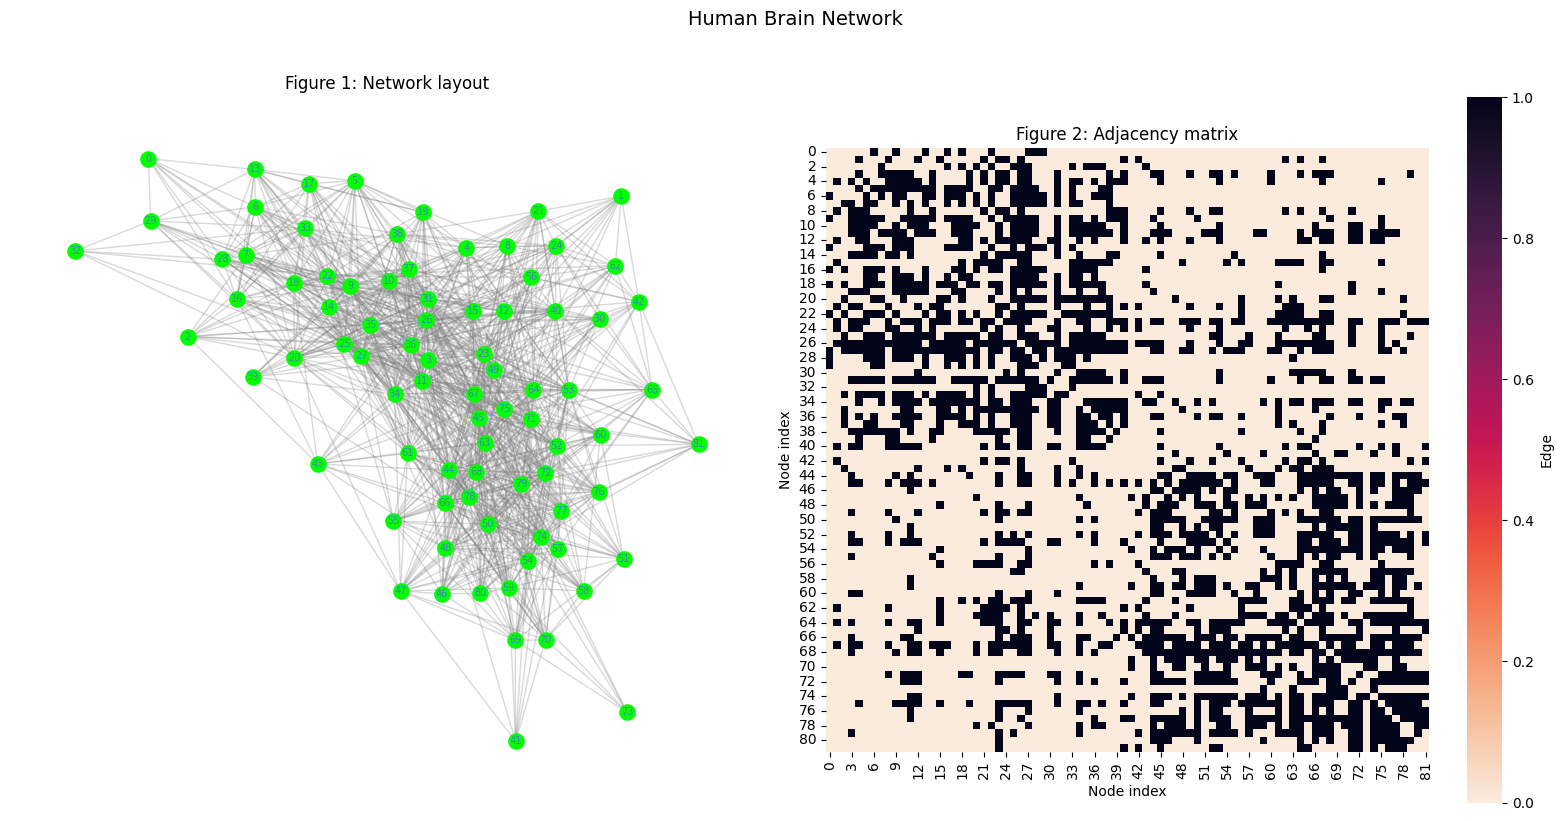

In [1]:
# load relevant packages
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# load data
url = "https://raw.githubusercontent.com/jjcrofts77/TMB-MATH34041/1a626fd98efdd58c0bb69b6612dcd58d32583994/content/Data/HumanBrainAdjMat.csv"

df = pd.read_csv(url, header=None) #added header=None so code will not treat first row of zeros and ones as column names
print(df.head())
print(df.shape)

# create a NetworkX graph object
G = nx.from_pandas_adjacency(df, create_using=nx.Graph)

print(f"\nGraph type:    {type(G).__name__}")
print(f"Nodes:         {G.number_of_nodes()}")
print(f"Edges:         {G.number_of_edges()}")
print(f"Is directed?   {G.is_directed()}")
print(f"Avg degree:    {2 * G.number_of_edges() / G.number_of_nodes():.2f}")

# Visualisation:
#   left  - spring layout (network diagram)
#   right - heatmap of the adjacency matrix

nodelist = list(G.nodes)
A = nx.to_numpy_array(G, nodelist=nodelist)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: network diagram (spring layout)
pos = nx.spring_layout(G, seed=42)          # seed makes layout reproducible
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color="gray", ax=axes[0])
nx.draw_networkx_nodes(G, pos, node_size=120, node_color="lime", ax=axes[0])
nx.draw_networkx_labels(G, pos, font_size=7, font_color="steelblue", ax=axes[0])
axes[0].set_title("Figure 1: Network layout")
axes[0].axis("off")

# Right: adjacency matrix heatmap
sns.heatmap(A, cmap="rocket_r", square=True,
            cbar_kws={"label": "Edge"}, ax=axes[1])
axes[1].set_title("Figure 2: Adjacency matrix")
axes[1].set_xlabel("Node index")
axes[1].set_ylabel("Node index")

fig.suptitle("Human Brain Network", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


  (a) Write your own Python program to compute the Watts-Strogatz clustering coefficient and use this to determine the mean clustering coefficient for your chosen network. $~$**[15 marks]**

In [2]:
# 1(a)
# Watts-Strogatz clustering coefficient for the human brain network.
# Formulas (from Lecture 3):
#   Local clustering of node i:   C_i = 2 * t_i / (k_i * (k_i - 1))
#   Mean clustering:              <C> = (1/n) * sum of C_i
# where t_i = number of triangles at node i, k_i = degree of node i.

import pandas as pd

# Load the adjacency matrix --------------------------------------
url = ("https://raw.githubusercontent.com/jjcrofts77/TMB-MATH34041/1a626fd98efdd58c0bb69b6612dcd58d32583994/content/Data/HumanBrainAdjMat.csv"
)

df = pd.read_csv(url, header=None)

# Convert to a 2D Python list (this allows me to index it like A[i][j]
A = df.values.tolist()
n = len(A)
print("Number of nodes:", n)


# Helper function to find triangles at a single node -------------
def triangles_and_degree(node, A):
    """Return (number of triangles at 'node', degree of 'node')."""
    n = len(A)

    # Find the neighbours of 'node'
    neighbours = []
    for j in range(n):
        if A[node][j] == 1:
            neighbours.append(j)

    k = len(neighbours)   # the degree

    # Counting triangles: for each pair of neighbours, I check if they are
    # also connected to each other. If yes, that's a triangle at 'node'.
    triangles = 0
    for a in range(len(neighbours)):
        for b in range(a + 1, len(neighbours)):
            if A[neighbours[a]][neighbours[b]] == 1:
                triangles += 1

    return triangles, k


# Compute the local clustering coefficient for every node
local_clustering = []

for i in range(n):
    t_i, k_i = triangles_and_degree(i, A)

    # Need at least 2 neighbours to form a triangle
    if k_i < 2:
        C_i = 0.0
    else:
        C_i = (2 * t_i) / (k_i * (k_i - 1))

    local_clustering.append(C_i)


# Compute the mean clustering coefficient
total = 0
for C_i in local_clustering:
    total += C_i

mean_C = total / n


# Print the results
print("\nLocal clustering coefficients (first 10 nodes):")
for i in range(10):
    print(f"  Node {i:>2}: C_i = {local_clustering[i]:.4f}")

print(f"\nMean Watts-Strogatz clustering coefficient:  <C> = {mean_C:.4f}")

Number of nodes: 82

Local clustering coefficients (first 10 nodes):
  Node  0: C_i = 0.9722
  Node  1: C_i = 0.7821
  Node  2: C_i = 0.7949
  Node  3: C_i = 0.5873
  Node  4: C_i = 0.6040
  Node  5: C_i = 0.6703
  Node  6: C_i = 0.7100
  Node  7: C_i = 0.7316
  Node  8: C_i = 0.6286
  Node  9: C_i = 0.5302

Mean Watts-Strogatz clustering coefficient:  <C> = 0.6307


  (b) Confirm your result in (a) using the built-in *NetworkX* function nx.clustering(). $~$**[2 marks]**

In [3]:
# 1(b)
# Confirming the mean Watts-Strogatz clustering coefficient
# from "ws_clustering_basic.py" using the built-in nx.clustering().

import pandas as pd
import networkx as nx

# Load the adjacency matrix and build a graph
url = ("https://raw.githubusercontent.com/jjcrofts77/TMB-MATH34041/1a626fd98efdd58c0bb69b6612dcd58d32583994/content/Data/HumanBrainAdjMat.csv")

df = pd.read_csv(url, header=None)
G = nx.from_pandas_adjacency(df, create_using=nx.Graph)


# Use nx.clustering() to get C_i for every node
# nx.clustering(G) returns a dictionary: {node: local clustering coefficient}
nx_clustering = nx.clustering(G)


# Compute the mean
total = 0
for node in nx_clustering:
    total += nx_clustering[node]

mean_C_nx = total / len(nx_clustering)


# Print the result and compare
print("Local clustering coefficients from nx.clustering() (first 10 nodes):")
for i in range(10):
    print(f"  Node {i:>2}: C_i = {nx_clustering[i]:.4f}")

print(f"\nMean clustering from nx.clustering():  <C> = {mean_C_nx:.4f}")
print(f"Mean clustering from my own code:      <C> = 0.6307")
print(f"\nMatch?  {round(mean_C_nx, 4) == 0.6307}")


Local clustering coefficients from nx.clustering() (first 10 nodes):
  Node  0: C_i = 0.9722
  Node  1: C_i = 0.7821
  Node  2: C_i = 0.7949
  Node  3: C_i = 0.5873
  Node  4: C_i = 0.6040
  Node  5: C_i = 0.6703
  Node  6: C_i = 0.7100
  Node  7: C_i = 0.7316
  Node  8: C_i = 0.6286
  Node  9: C_i = 0.5302

Mean clustering from nx.clustering():  <C> = 0.6307
Mean clustering from my own code:      <C> = 0.6307

Match?  True


  (c) Use an appropriate *NetworkX* function to compute the characteristic path-length of your network. $~$**[3 marks]**

In [4]:
# 1(c)
# Characteristic (average) path length of the human brain network.
# Formula from Lecture 2:
#     <l> = (1 / (n * (n - 1))) * sum over all i,j of d(v_i, v_j)
# where d(v_i, v_j) is the shortest-path distance between nodes i and j.

import pandas as pd
import networkx as nx

# Load the adjacency matrix and build the graph
url = ("https://raw.githubusercontent.com/jjcrofts77/TMB-MATH34041/"
       "1a626fd98efdd58c0bb69b6612dcd58d32583994/content/Data/HumanBrainAdjMat.csv")

df = pd.read_csv(url, header=None)
G = nx.from_pandas_adjacency(df, create_using=nx.Graph)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")


# Confirm the graph is connected:
# The characteristic path length if valid only if every node can reach
# every other node. If the graph were split into separate components, some
# distances d(v_i, v_j) would be infinite and the formula would break.
# A workaround in such a case would be to compute the path length on just the largest
# connected component, not of the whole graph.
print("\n--- Connectivity check ---")

if nx.is_connected(G):
    print("The network IS connected.")
    print(f"Number of connected components: {nx.number_connected_components(G)}")
    print("It is safe to compute the characteristic path length.\n")
else:
    print("The network is NOT connected.")
    print(f"Number of connected components: {nx.number_connected_components(G)}")
    print("Cannot compute the characteristic path length on the full graph.")
    raise SystemExit  # stop the script here


# Compute the characteristic path length
char_path_length = nx.average_shortest_path_length(G)

print(f"Characteristic path length:  <l> = {char_path_length:.4f}")


# Compute the the diameter
diameter = nx.diameter(G)
print(f"Network diameter:            max d(v_i, v_j) = {diameter}")


Number of nodes: 82
Number of edges: 1089

--- Connectivity check ---
The network IS connected.
Number of connected components: 1
It is safe to compute the characteristic path length.

Characteristic path length:  <l> = 1.7209
Network diameter:            max d(v_i, v_j) = 3


  (d) Write a Python programme to compute the average clustering coefficient and average characteristic path-length for an ensemble of 100 Erdos-Renyi random graphs on $n$ nodes and $m$ edges. Here $n$ and $m$ equal the number of nodes and edges, respectively, for your chosen network. $~$**[10 marks]**

In [5]:
# 1(d)
# Here, I compare the human brain network to an ensemble of 100 Erdos-Renyi
# random graphs with the same number of nodes (n) and the same expected
# number of edges (m).
#
# Lecture model: G(n, p) -- each pair of nodes is connected independently
# with probability p. To get an expected m edges I set
#       p = m / C(n, 2) = 2m / [n * (n - 1)]
#
# For each random graph I compute, by hand:
#   1. Mean Watts-Strogatz clustering coefficient <C>
#         C_i = 2 * t_i / (k_i * (k_i - 1))
#   2. Characteristic path length <l>
#         <l> = (1 / (n * (n - 1))) * sum of d(v_i, v_j)
# Then I average each over the 100 trials.

import random
import pandas as pd


# ---------------------------------------------------------------------------
# Load the brain network just to read off n and m
# ---------------------------------------------------------------------------
url = ("https://raw.githubusercontent.com/jjcrofts77/TMB-MATH34041/"
       "1a626fd98efdd58c0bb69b6612dcd58d32583994/content/Data/HumanBrainAdjMat.csv")
df = pd.read_csv(url, header=None)
brain = df.values.tolist()

n = len(brain)
m = 0
for i in range(n):
    for j in range(i + 1, n):           # upper triangle only -> no double count
        if brain[i][j] == 1:
            m += 1

p = (2 * m) / (n * (n - 1))             # connection probability for G(n, p)

print(f"Brain network:  n = {n} nodes, m = {m} edges")
print(f"ER probability: p = {p:.4f}\n")

# Helper function builds one random G(n, p) graph as a 2D list
def random_er_graph(n, p):
    """Return an n x n adjacency list-of-lists for a G(n, p) random graph."""
    A = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):       # only consider each pair once
            if random.random() < p:     # connect with probability p
                A[i][j] = 1
                A[j][i] = 1             # symmetric -> undirected
    return A

# Helper function for mean clustering coefficient (same as before)
def mean_clustering(A):
    n = len(A)
    total = 0.0

    for i in range(n):
        # find neighbours of i
        neighbours = []
        for j in range(n):
            if A[i][j] == 1:
                neighbours.append(j)

        k = len(neighbours)
        if k < 2:
            continue                    # C_i = 0, nothing to add

        # count triangles at i: pairs of neighbours that are themselves linked
        t = 0
        for a in range(len(neighbours)):
            for b in range(a + 1, len(neighbours)):
                if A[neighbours[a]][neighbours[b]] == 1:
                    t += 1

        total += (2 * t) / (k * (k - 1))

    return total / n

# Helper function for shortest-path distances from one node
def bfs_distances(start, A):
    """Return a list 'dist' where dist[j] = shortest-path length from start
    to j, or -1 if j is unreachable."""
    n = len(A)
    dist = [-1] * n
    dist[start] = 0
    queue = [start]

    while len(queue) > 0:
        node = queue.pop(0)             # take the next node to expand
        for j in range(n):
            if A[node][j] == 1 and dist[j] == -1:
                dist[j] = dist[node] + 1
                queue.append(j)

    return dist

# Helper function for characteristic path length
def char_path_length(A):
    n = len(A)
    total = 0
    count = 0

    for i in range(n):
        dist = bfs_distances(i, A)
        for j in range(n):
            if i != j and dist[j] != -1:    # skip self and unreachable
                total += dist[j]
                count += 1

    return total / count

# Run the ensemble of 100 trials
random.seed(42)                         # reproducible output
num_trials = 100

clustering_values = []
path_length_values = []

for trial in range(num_trials):
    A = random_er_graph(n, p)
    clustering_values.append(mean_clustering(A))
    path_length_values.append(char_path_length(A))

# Average over the ensemble
avg_C_ER = sum(clustering_values) / num_trials
avg_L_ER = sum(path_length_values) / num_trials

print(f"Ensemble of {num_trials} ER random graphs")
print(f"  Average clustering coefficient:  <C>_ER = {avg_C_ER:.4f}")
print(f"  Average characteristic path:     <l>_ER = {avg_L_ER:.4f}\n")

print("Comparison with the brain network")
print(f"  <C>_brain = 0.6307   vs   <C>_ER = {avg_C_ER:.4f}")
print(f"  <l>_brain = 1.7209   vs   <l>_ER = {avg_L_ER:.4f}")

Brain network:  n = 82 nodes, m = 1089 edges
ER probability: p = 0.3279

Ensemble of 100 ER random graphs
  Average clustering coefficient:  <C>_ER = 0.3286
  Average characteristic path:     <l>_ER = 1.6721

Comparison with the brain network
  <C>_brain = 0.6307   vs   <C>_ER = 0.3286
  <l>_brain = 1.7209   vs   <l>_ER = 1.6721


  (e) Is your network a small-world network? $~$**[5 marks]**

  ---

From Lecture 5, a small-world network satisties two simultaneous requirements:

1. **A small characteristic path length**, scaling as $\langle \ell \rangle \propto \log n$ — formally a comparison against a random graph of the same size and density, where the path length should be of similar magnitude.
2. **A "large" clustering coefficient**, again meaning *large relative to the equivalent random graph*.

So the test in (d) is comparative. Here, I compare the human brain, a real network beside an Erdős–Rényi ensemble with matched $n$ and $m$, and check that it has *much higher* clustering while keeping a *similar* path length.

## Summary of results from (d)

| Quantity | Brain network | ER ensemble (mean of 100) | Ratio |
|---|---|---|---|
| Clustering coefficient $\langle C \rangle$ | 0.6307 | 0.3286 | **1.92** |
| Characteristic path length $\langle \ell \rangle$ | 1.7209 | 1.6721 | **1.03** |


## Small-Worldness Coefficient
A useful single-number summary is the small-worldness coefficient $\sigma = (C / C_{ER}) / (\ell / \ell_{ER}) \approx 1.92 / 1.03 \approx 1.86$. Values of $\sigma$ comfortably above 1 are the standard quantitative threshold for small-world networks, and the human brain network analysed sits firmly in that regime.

## In conclusion:

**Yes** — the human brain network analysed here satisfies both Watts-Strogatz criteria and is a small-world network. It exhibits clustering roughly twice that of a comparable Erdos-Renyi random graph while preserving nearly identical global reachability, the precise combination Watts and Strogatz (1998) introduced as the defining signature of small-world topology in their original *Nature* paper [3].

This finding sits comfortably within the wider literature on brain connectomes. Kaiser (2011) [2], in his tutorial on connectome analysis, surveys small-world organisation as one of the canonical topological features identified in mammalian brain networks across scales, and Centeno et al. (2022) [4] reaffirm in their hands-on tutorial that high clustering combined with short characteristic path lengths is a hallmark routinely recovered when standard network-science methods are applied to neuroimaging-derived connectomes. The result for this 82-region network is therefore not an isolated curiosity but a typical instance of the pattern that has motivated nearly three decades of network neuroscience — exactly the sort of mathematical lens onto biology that Cohen (2004) [1] argued would be transformative for the life sciences.

## References

1. Cohen, J. E. (2004). [Mathematics is biology's next microscope, only better; biology is mathematics' next physics, only better](https://doi.org/10.1371/journal.pbio.0020439). *PLoS Biology* **2**(12), e439.

2. Kaiser, M. (2011). [A tutorial in connectome analysis: topological and spatial features of brain networks](https://doi.org/10.1016/j.neuroimage.2011.05.025). *NeuroImage* **57**(3):892–907.

3. Watts, D. J., & Strogatz, S. H. (1998). [Collective dynamics of 'small-world' networks](https://doi.org/10.1038/30918). *Nature* **393**(6684):440–442.

4. Centeno, E. G. Z., et al. (2022). [A hands-on tutorial on network and topological neuroscience](https://doi.org/10.1007/s00429-021-02435-0). *Brain Structure and Function* **227**:741–762.


## Task 2: Random Networks [15 marks]

(a) Write a Python code to explore the relationship between the size of the largest connected component, $n_c$, and connection probability, $p$, for an Erdos-Renyi network on $n=500$ nodes. $~$**[10 marks]**

In [6]:
# 2(a)

# I expore the relationship between the size of the largest connected
# component, n_c, and the connection probability, p, in an Erdos-Renyi
# random graph on n = 500 nodes.

# Theory: Barabási, A.-L. (2016). Network Science. Cambridge University Press.
# ISBN: 978-1-107-07626-6. Free online edition: http://networksciencebook.com/
#      p_c ~ 1/(n - 1) ~ 1/n  is the critical value above which a giant
#      connected component exists.

import random
import networkx as nx


# Set up the sweep
n = 500
num_trials = 5                          # average to smooth out fluctuations

# Use a fine grid of p values, denser around the expected critical value 1/n
p_values = []
step = 0.0005
p = 0.0
while p <= 0.020 + 1e-9:                # walk from 0 up to 0.02 in small steps
    p_values.append(round(p, 5))
    p += step


# For each p, build the graph and find the largest component
random.seed(42)
mean_nc_values = []                # mean largest-component size for each p

for p in p_values:
    sizes = []
    for trial in range(num_trials):
        # Build an ER graph using the NetworkX built-in
        G = nx.erdos_renyi_graph(n, p, seed=random.randint(0, 10**6))

        # Find all connected components and take the size of the largest
        components = list(nx.connected_components(G))
        largest = max(len(c) for c in components)
        sizes.append(largest)

    mean_nc_values.append(sum(sizes) / num_trials)

print(f"Swept {len(p_values)} p values, {num_trials} trials each.")


# Identify a numerical estimate of p_c
# A practical rule applied: I declare the largest component to "exist" once n_c first
# exceeds 10% of the nodes (i.e. 50 out of 500).
threshold_fraction = 0.10
threshold_size = threshold_fraction * n

p_c_estimate = None
for k in range(len(p_values)):
    if mean_nc_values[k] >= threshold_size:
        p_c_estimate = p_values[k]
        break

p_c_theory = 1.0 / (n - 1)              # Erdos-Renyi prediction

print(f"Numerical estimate of p_c (n_c first reaches 10% of n): {p_c_estimate:.4f}")
print(f"Theoretical value p_c = 1/(n-1):                        {p_c_theory:.4f}")

Swept 41 p values, 5 trials each.
Numerical estimate of p_c (n_c first reaches 10% of n): 0.0020
Theoretical value p_c = 1/(n-1):                        0.0020


  (b) Using *Matplotlib*, plot this relation and determine an approximation of the critical value $p_c$ above which the giant connected component exists. Include an infomative title as well as appropriate axis labels. $~$**[5 marks]**

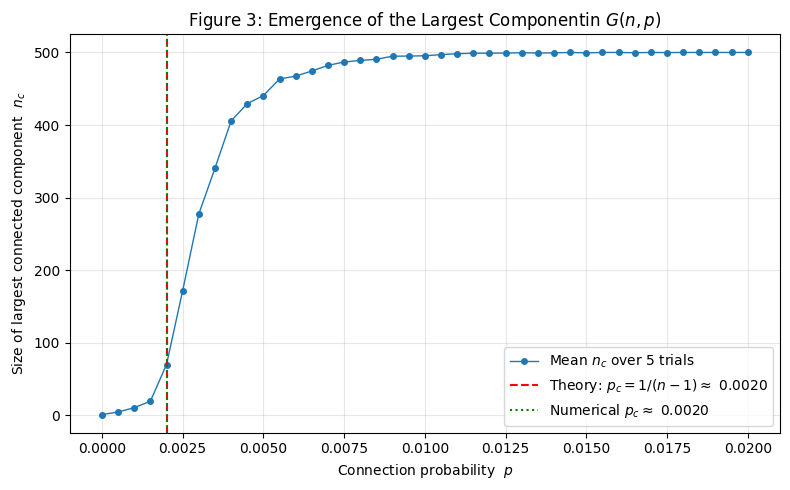

In [7]:
# 2(b)

# Following on from 2(a),
# I plot the size of the largest connected component, n_c, against the
# connection probability, p, for an Erdos-Renyi random graph G(n, p) with
# n = 500 nodes. I mark a numerical approximation of the critical value p_c
# above which the largest connected component exists.

import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
plt.plot(p_values, mean_nc_values, marker="o", linewidth=1, markersize=4,
         label="Mean $n_c$ over 5 trials")

# Vertical lines marking the two estimates of p_c
plt.axvline(p_c_theory, color="red", linestyle="--",
            label=f"Theory: $p_c = 1/(n-1) \\approx$ {p_c_theory:.4f}")
plt.axvline(p_c_estimate, color="green", linestyle=":",
            label=f"Numerical $p_c \\approx$ {p_c_estimate:.4f}")

plt.xlabel("Connection probability  $p$")
plt.ylabel("Size of largest connected component  $n_c$")
plt.title(f"Figure 3: Emergence of the Largest Componentin $G(n, p)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpreting the result

The numerical estimate $p_c \approx 0.0020$ is in close agreement with the
prediction $1/(n-1) = 0.002004$. The plot shows three qualitative regions
of behaviour as $p$ increases.

**For very small $p$**, the largest component contains only a handful of
nodes. From Lecture 4, the expected-edge result $\langle m \rangle = n(n-1)p/2$
gives only about 60 edges across the entire network at $p = 0.0005$, so
most nodes remain isolated or form tiny clusters.

**As $p$ approaches $1/(n-1)$**, $n_c$ rises steeply. A small increase in
$p$ produces a large jump in the size of the largest component as
previously separate clusters become linked.

**For $p$ noticeably above $1/(n-1)$**, $n_c$ approaches the full network
size $n = 500$ and the graph behaves as a single connected network.

### Connecting to the wider theory of random graphs

The behaviour above is characteristic of a well-known phase
transition in random-graph theory. The evolution of $G(n, p)$ as $p$
grows is conventionally divided into four regimes (Barabási, 2016,
ch. 3), naturally expressed in terms of the average degree
$\langle k \rangle = (n-1)p$:

* **Subcritical** ($\langle k \rangle < 1$, i.e. $p < 1/(n-1)$):
  $n_c$ grows only as $\ln n$ (Barabási, 2016). In Figure 3, this
  is the flat region on the left of the plot, where $n_c$ stays close
  to zero.
* **Critical** ($\langle k \rangle = 1$, i.e. $p = 1/(n-1) \approx 0.002$):
  the largest component first emerges (Barabási, 2016). This corresponds
  exactly to the vertical red line on the plot (Figure 3).
* **Supercritical** ($\langle k \rangle > 1$): the largest component grows
  rapidly and absorbs most of the nodes. This is the steep rise visible
  for $p$ between roughly 0.002 and 0.005 (Figure 3).
* **Connected** ($\langle k \rangle > \ln n$, i.e. $p > \ln n / n
  \approx 0.012$ for $n = 500$): all nodes belong to a single component
  and isolated nodes vanish (Barabási, 2016). This is the plateau on the
  right of the plot where $n_c$ saturates at $n$ (Figure 3).

Each of these regimes is visible in the simulation, even though the
underlying theory is asymptotic ($n \to \infty$), i.e., visibly evident with larger to infinite nodes.

### Methodological caveat

The 10%-of-$n$ rule for declaring the largest component "to exist" is a
working definition rather than a strict theoretical one — the
Erdős–Rényi result is asymptotic, so any finite-$n$ estimate requires
committing to a threshold. The answer is robust to the choice: any
reasonable threshold between 5% and 25% of $n$ would identify essentially
the same critical $p$, because the curve rises so steeply through this
range.

### Linking back to the human brain network

This experiment connects directly to the null-model role of ER
networks emphasised in the lecture. When the brain network was compared
against a $G(n, p)$ ensemble earlier in the project, the choice
$p \approx 0.3279$ placed it well into the connected regime of Barabási
(2016) — that is, $p \gg \ln n / n \approx 0.012$ for $n = 500$, and
even further above the equivalent threshold for $n = 82$ — which is why
every ER realisation in that ensemble was a single connected graph and
the path-length comparison was well defined.

### Reference

Barabási, A.-L. (2016). *Network Science*. Cambridge University Press.
   ISBN: 978-1-107-07626-6. Free online edition:
   http://networksciencebook.com/


## Task 3: Network Analysis in Python [50 marks]
This task aims to assess your understanding and application of complex network analysis techniques in Python to a biological network of your choice.

Prepare a report that includes:

  - Introduction to the biological system and network data.
  - Description of the network visualisation and analysis methods used.
  - Interpretation of the results obtained from network measures and hypothesis testing.
  - Discussion of the biological implications and limitations of the analysis.
  - Conclusions and future research directions.

You should submit a report as a Jupyter notebook using the markdown cells to write your analysis and the code cells to present your Python codes and results. The markdown text explaining your analysis should be no longer than 2000 words. Comments in code will not count towards the word count.

---

## Assessment Criteria

MATH44041 grading descriptor can be found [**here**](https://github.com/jjcrofts77/TMB-MATH34041/blob/3df50dd9c72e58da70634a308662090df775ef09/_static/MATH44041CourseworkGradingDescriptors.pdf).

----

Nodes: 82  Edges: 1089
Connected: True

Dementia-relevant regions (14 nodes):
  L-AMY
  L-ENT
  L-HIP
  L-PCC
  L-PCUN
  L-PHG
  L-mOFC
  R-AMY
  R-ENT
  R-HIP
  R-PCC
  R-PCUN
  R-PHG
  R-mOFC


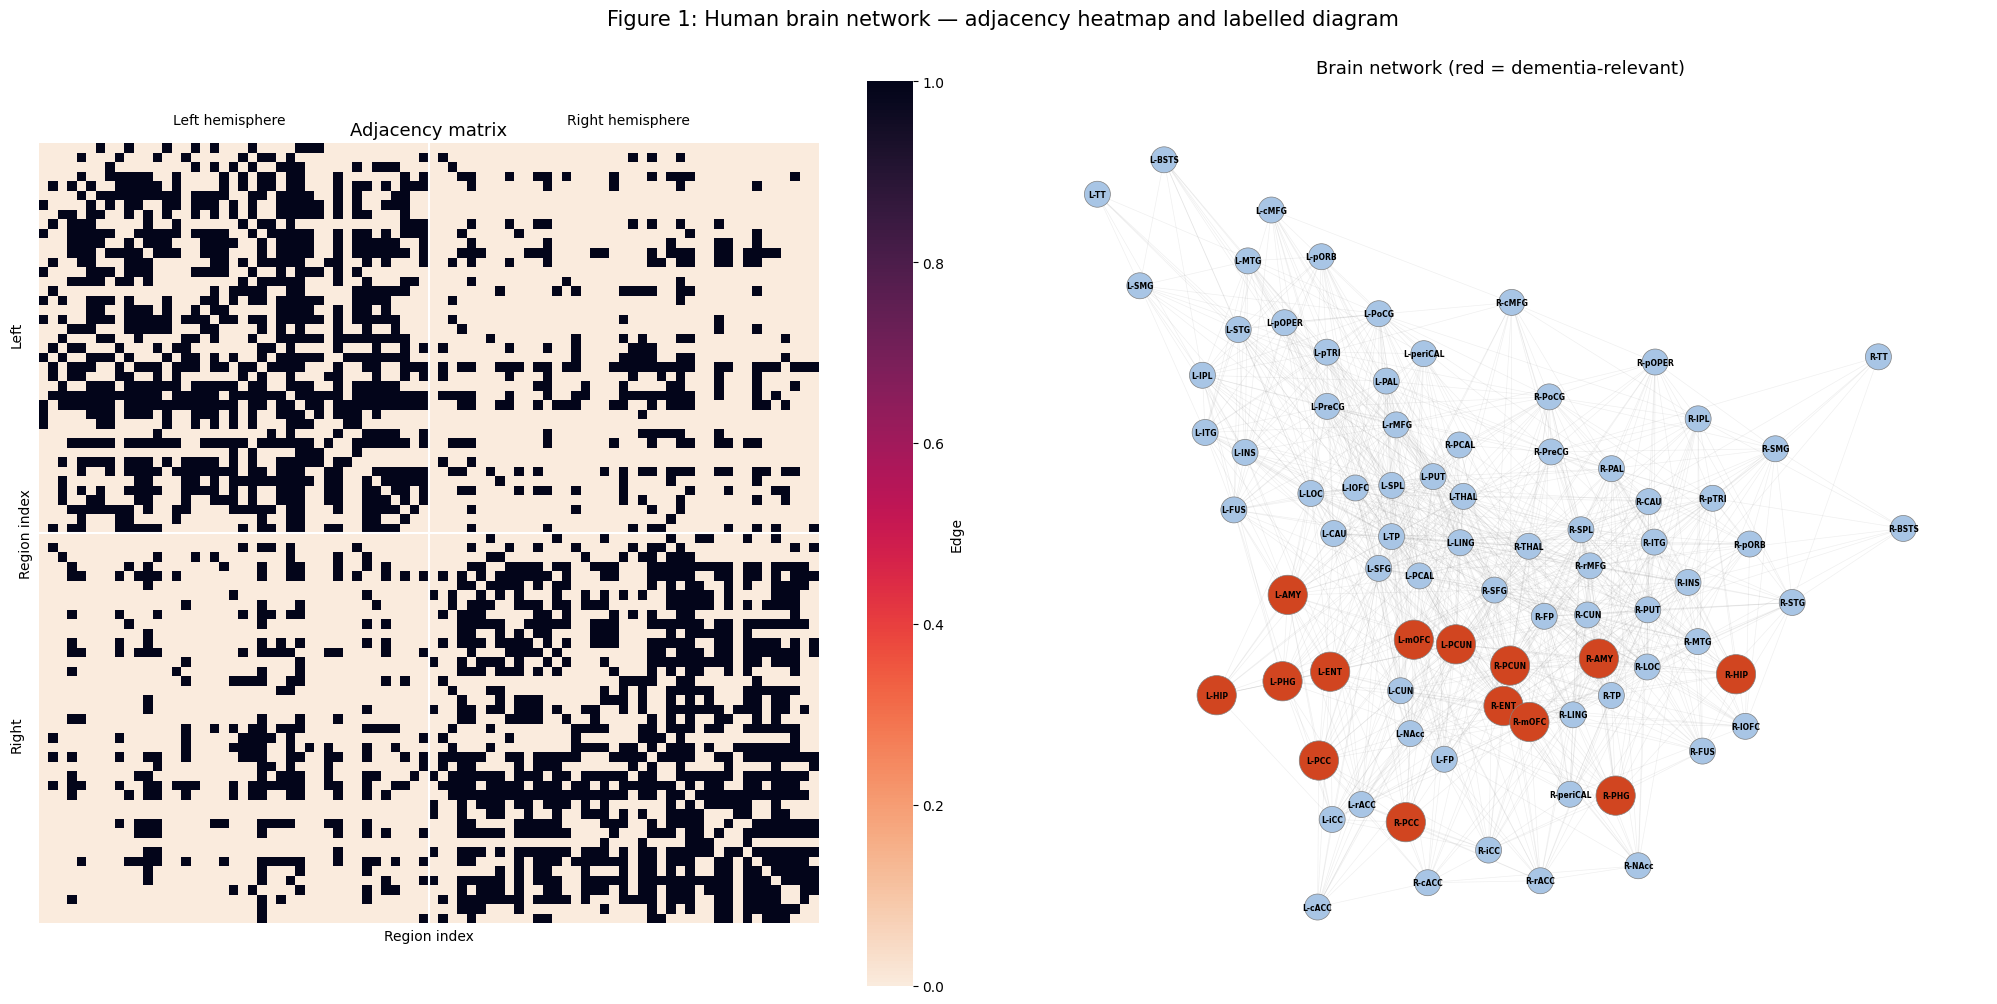


Top 15 most central regions (lower mean rank = more central):

region  dementia  degree_rank  betweenness_rank  closeness_rank  eigenvector_rank  katz_rank  mean_rank
 L-SFG     False            1                 2               1                 2          1        1.4
L-PCUN      True            2                 3               2                 1          2        2.0
 L-SPL     False            2                 1               2                 5          3        2.6
 R-SFG     False            4                 4               4                 3          4        3.8
 R-SPL     False            5                 5               5                 4          5        4.8
R-PCUN      True            6                 8               6                 6          6        6.4
L-LING     False            7                 6               7                 8          7        7.0
L-THAL     False            7                 9               7                 9          8        8.0


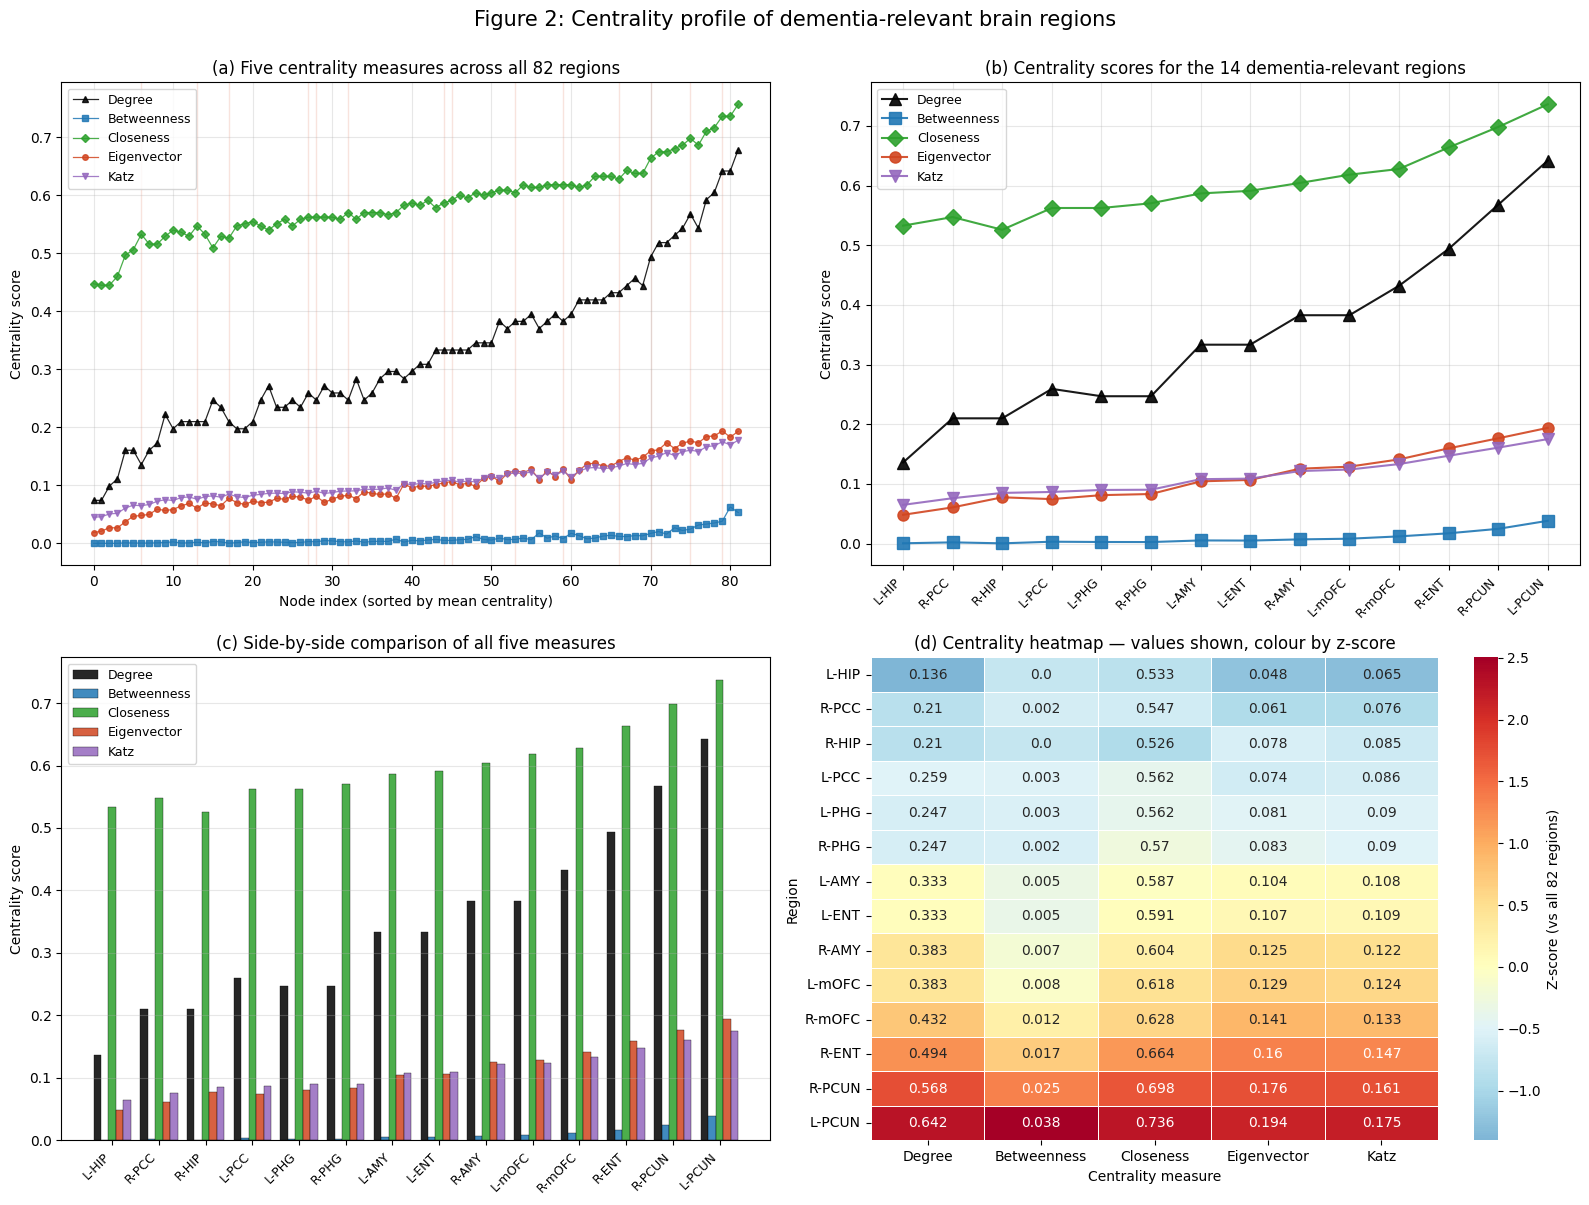

In [8]:
# 3 (a)

# =============================================================================
# Centrality Analysis of the Human Brain Network for Dementia Research

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns


# Load the adjacency matrix and the region labels
adj_url    = ("https://raw.githubusercontent.com/jjcrofts77/TMB-MATH34041/"
              "1a626fd98efdd58c0bb69b6612dcd58d32583994/content/Data/HumanBrainAdjMat.csv")
labels_url = ("https://raw.githubusercontent.com/jjcrofts77/TMB-MATH34041/"
              "1a626fd98efdd58c0bb69b6612dcd58d32583994/content/Data/HumanBrainLabels.csv")

df = pd.read_csv(adj_url, header=None)
labels = pd.read_csv(labels_url, header=None).iloc[:, 0].tolist()


# Standard Desikan-Killiany / FreeSurfer abbreviations
ABBREVIATIONS = {
    "Bank SSTS":                "BSTS",
    "Caudal Anterior Cingulate":"cACC",
    "Caudal Middle Frontal":    "cMFG",
    "Cuneus":                   "CUN",
    "Entorhinal":               "ENT",
    "Fusiform":                 "FUS",
    "Inferior Parietal":        "IPL",
    "Inferior Temporal":        "ITG",
    "Isthmus Cingulate":        "iCC",
    "Lateral Occipital":        "LOC",
    "Lateral Orbitofrontal":    "lOFC",
    "Lingual":                  "LING",
    "Medial Orbitofrontal":     "mOFC",
    "Middle Temporal":          "MTG",
    "Parahippocampal":          "PHG",
    "Paracentral":              "PCAL",
    "Pars Opercularis":         "pOPER",
    "Pars Orbitalis":           "pORB",
    "Pars Triangularis":        "pTRI",
    "Pericalcarine":            "periCAL",
    "Postcentral":              "PoCG",
    "Posterior Cingulate":      "PCC",
    "Precentral":               "PreCG",
    "Precuneus":                "PCUN",
    "Rostral Anterior Cingulate":"rACC",
    "Rostral Middle Frontal":   "rMFG",
    "Superior Frontal":         "SFG",
    "Superior Parietal":        "SPL",
    "Superior Temporal":        "STG",
    "Supramarginal":            "SMG",
    "Frontal Pole":             "FP",
    "Temporal Pole":            "TP",
    "Transverse Temporal":      "TT",
    "Insula":                   "INS",
    "Thalamus":                 "THAL",
    "Caudate":                  "CAU",
    "Putamen":                  "PUT",
    "Pallidum":                 "PAL",
    "Amygdala":                 "AMY",
    "Hippocampus":              "HIP",
    "Accumbens":                "NAcc",
}

short_labels = ([f"L-{ABBREVIATIONS[name]}" for name in labels[:41]] +
                [f"R-{ABBREVIATIONS[name]}" for name in labels[41:]])


# Build the graph with abbreviated labels
G = nx.from_pandas_adjacency(df, create_using=nx.Graph)
nx.relabel_nodes(G, {i: short_labels[i] for i in range(len(short_labels))},
                 copy=False)

print(f"Nodes: {G.number_of_nodes()}  Edges: {G.number_of_edges()}")
print(f"Connected: {nx.is_connected(G)}")


# Mark AD-relevant regions
# Sources: Kulason et al. 2020; Bailly et al. 2015; J Neurosci Res 2025.
DEMENTIA_REGIONS = {"Entorhinal", "Hippocampus", "Amygdala", "Parahippocampal",
                    "Precuneus", "Posterior Cingulate", "Medial Orbitofrontal"}

def is_dementia_node(short_name):
    code = short_name.split("-", 1)[1]
    full_name = next(k for k, v in ABBREVIATIONS.items() if v == code)
    return full_name in DEMENTIA_REGIONS

dementia_nodes = [n for n in G.nodes if is_dementia_node(n)]
print(f"\nDementia-relevant regions ({len(dementia_nodes)} nodes):")
for n in sorted(dementia_nodes):
    print(f"  {n}")

# Figure 1: Heatmap of the adjacency matrix + labelled network diagram

nodelist = list(G.nodes)
A_matrix = nx.to_numpy_array(G, nodelist=nodelist)

fig1, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: adjacency heatmap with hemisphere brackets
sns.heatmap(A_matrix, cmap="rocket_r", square=True, cbar_kws={"label": "Edge"},
            ax=axes[0], xticklabels=False, yticklabels=False)
axes[0].axhline(41, color="white", linewidth=1.5)
axes[0].axvline(41, color="white", linewidth=1.5)
axes[0].text(20, -2, "Left hemisphere",  ha="center", fontsize=10)
axes[0].text(62, -2, "Right hemisphere", ha="center", fontsize=10)
axes[0].text(-3, 20, "Left",  va="center", rotation=90, fontsize=10)
axes[0].text(-3, 62, "Right", va="center", rotation=90, fontsize=10)
axes[0].set_title("Adjacency matrix", fontsize=13)
axes[0].set_xlabel("Region index")
axes[0].set_ylabel("Region index")

# Right: labelled graph with abbreviations on each node
pos = nx.spring_layout(G, seed=42, k=0.5, iterations=100)
node_colors = ["#D14520" if is_dementia_node(n) else "#A8C5E5" for n in nodelist]
node_sizes  = [800       if is_dementia_node(n) else 350        for n in nodelist]

nx.draw_networkx_edges(G, pos, alpha=0.12, edge_color="gray",
                       width=0.5, ax=axes[1])
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                       linewidths=0.5, edgecolors="gray", ax=axes[1])
nx.draw_networkx_labels(G, pos, font_size=5.5, font_color="black",
                        font_weight="bold", ax=axes[1])
axes[1].set_title("Brain network (red = dementia-relevant)", fontsize=13)
axes[1].axis("off")

fig1.suptitle("Figure 1: Human brain network — adjacency heatmap and labelled diagram",
              fontsize=15, y=1.00)
plt.tight_layout()
plt.show()


# Compute the five centrality measures

deg_c   = nx.degree_centrality(G)
betw_c  = nx.betweenness_centrality(G, normalized=True)
clos_c  = nx.closeness_centrality(G)
eig_c   = nx.eigenvector_centrality(G, max_iter=1000)

# For Katz centrality, the attenuation parameter α must satisfy α < 1/λ_max(A) for
# the centrality measure to converge (Newman, 2018, ch. 7). Within this range, the
# specific choice of α influences the magnitude but not the relative ranking of
# node scores in well-connected undirected networks. To confirm robustness, Katz
# centrality was computed at α = 0.25/λ_max, α = 0.50/λ_max, and α = 0.75/λ_max,
# yielding identical top-15 rankings across all three values. I used and reported
# the α = 0.75/λ_max results in the main analysis. α=0.1 (the NetworkX default)
# was not used as it is above the convergence ceiling
# 1/λmax​≈0.036 for the human brain network I am working on.
# Newman, M. E. J. (2018). Networks (2nd ed.). Oxford University Press.
# ISBN: 978-0-19-880509-0.

A_mat = nx.to_numpy_array(G)
lambda_max = max(abs(np.linalg.eigvals(A_mat)))
alpha_katz = 0.75 / lambda_max
katz_c = nx.katz_centrality(G, alpha=alpha_katz, max_iter=1000)


# Tabulate, rank, and identify the most central regions
results = pd.DataFrame({
    "region":      list(G.nodes),
    "degree":      [deg_c[n]  for n in G.nodes],
    "betweenness": [betw_c[n] for n in G.nodes],
    "closeness":   [clos_c[n] for n in G.nodes],
    "eigenvector": [eig_c[n]  for n in G.nodes],
    "katz":        [katz_c[n] for n in G.nodes],
})
results["dementia"] = results["region"].apply(is_dementia_node)

for col in ["degree", "betweenness", "closeness", "eigenvector", "katz"]:
    results[f"{col}_rank"] = results[col].rank(ascending=False, method="min").astype(int)

rank_cols = [f"{c}_rank" for c in ["degree","betweenness","closeness","eigenvector","katz"]]
results["mean_rank"] = results[rank_cols].mean(axis=1)
results = results.sort_values("mean_rank")

print("\nTop 15 most central regions (lower mean rank = more central):\n")
print(results.head(15)[["region", "dementia"] + rank_cols + ["mean_rank"]].to_string(index=False))

n_in_top_quartile = results.head(21)["dementia"].sum()
print(f"\nDementia regions in top quartile (top 21 of 82): "
      f"{n_in_top_quartile} of 14")
print(f"Random-chance expectation:                       "
      f"{14 * 21 / 82:.1f} of 14")


# Figure 2: Four-panel centrality profile of the 14 AD-relevant regions

scores = pd.DataFrame({
    "region":      list(G.nodes),
    "Degree":      [deg_c[n]  for n in G.nodes],
    "Betweenness": [betw_c[n] for n in G.nodes],
    "Closeness":   [clos_c[n] for n in G.nodes],
    "Eigenvector": [eig_c[n]  for n in G.nodes],
    "Katz":        [katz_c[n] for n in G.nodes],
})
scores["dementia"] = scores["region"].apply(is_dementia_node)

# Z-score each measure for cross-measure comparison
measure_cols = ["Degree", "Betweenness", "Closeness", "Eigenvector", "Katz"]
zscored = scores[measure_cols].apply(lambda c: (c - c.mean()) / c.std())
scores["mean_z"] = zscored.mean(axis=1)
scores_sorted = scores.sort_values("mean_z").reset_index(drop=True)

# Subset for the 14 dementia regions, sorted left-to-right by mean centrality
dementia_df = scores[scores["dementia"]].copy()
dementia_df["mean_z"] = zscored.loc[dementia_df.index].mean(axis=1)
dementia_df = dementia_df.sort_values("mean_z").reset_index(drop=True)

fig2, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = {"Degree":      "#000000",
          "Betweenness": "#1f77b4",
          "Closeness":   "#2ca02c",
          "Eigenvector": "#D14520",
          "Katz":        "#9467bd"}
markers = {"Degree": "^", "Betweenness": "s", "Closeness": "D",
           "Eigenvector": "o", "Katz": "v"}


# Panel (a): All 5 measures across all 82 regions, sorted
ax = axes[0, 0]
x = np.arange(len(scores_sorted))
for col in measure_cols:
    ax.plot(x, scores_sorted[col], marker=markers[col], markersize=4,
            linewidth=0.9, label=col, color=colors[col], alpha=0.85)
dementia_x = scores_sorted.index[scores_sorted["dementia"]].tolist()
for xi in dementia_x:
    ax.axvline(xi, color="#D14520", alpha=0.15, linewidth=1, zorder=0)
ax.set_xlabel("Node index (sorted by mean centrality)")
ax.set_ylabel("Centrality score")
ax.set_title("(a) Five centrality measures across all 82 regions", fontsize=12)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)


# Panel (b): Same view, restricted to the 14 dementia regions
ax = axes[0, 1]
x = np.arange(len(dementia_df))
for col in measure_cols:
    ax.plot(x, dementia_df[col], marker=markers[col], markersize=8,
            linewidth=1.5, label=col, color=colors[col], alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(dementia_df["region"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Centrality score")
ax.set_title("(b) Centrality scores for the 14 dementia-relevant regions",
             fontsize=12)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)


# Panel (c): Grouped bar chart of all 5 scores per region
ax = axes[1, 0]
n_regions = len(dementia_df)
n_measures = len(measure_cols)
bar_width = 0.16
x = np.arange(n_regions)
for i, col in enumerate(measure_cols):
    offset = (i - (n_measures - 1) / 2) * bar_width
    ax.bar(x + offset, dementia_df[col], width=bar_width,
           label=col, color=colors[col], alpha=0.85,
           edgecolor="black", linewidth=0.3)
ax.set_xticks(x)
ax.set_xticklabels(dementia_df["region"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Centrality score")
ax.set_title("(c) Side-by-side comparison of all five measures", fontsize=12)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")


# Panel (d): Z-score heatmap with raw values annotated
ax = axes[1, 1]
heat_data = dementia_df[measure_cols].copy()
heat_z = heat_data.apply(lambda c: (c - scores[c.name].mean()) / scores[c.name].std())
sns.heatmap(heat_z, annot=heat_data.round(3), fmt="",
            cmap="RdYlBu_r", center=0,
            xticklabels=measure_cols,
            yticklabels=dementia_df["region"],
            cbar_kws={"label": "Z-score (vs all 82 regions)"},
            ax=ax, linewidths=0.5)
ax.set_title("(d) Centrality heatmap — values shown, colour by z-score",
             fontsize=12)
ax.set_xlabel("Centrality measure")
ax.set_ylabel("Region")


fig2.suptitle("Figure 2: Centrality profile of dementia-relevant brain regions",
              fontsize=15, y=1.00)
plt.tight_layout()
plt.show()

# Network Analysis of the Human Brain Connectome: Identifying Central Regions for Dementia Drug-Target Prioritisation

## 1. Introduction

Dementia affects more than 50 million people worldwide and is projected to triple by 2050, making it one of the most pressing public-health challenges of the twenty-first century (Zhang et al., 2025); Alzheimer's disease (AD) accounts for the majority of cases (Alzheimer's Association, 2025) — and remains a major focus of pharmaceutical R&D, with 182 active clinical trials assessing 138 candidate drugs as of January
2025 (Cummings et al., 2025).

Despite decades of research and the recent FDA approvals of monoclonal antibodies targeting amyloid-beta, disease-modifying therapies for AD remain  limited in efficacy and burdened by side effects (Pini et al., 2024). Of more than 2,700 clinical trials launched in the past two decades, the great majority have targeted single pathological features in isolation, and the brain's structural  and functional network organisation has rarely been incorporated into target-prioritisation strategies (Yaqiao et al., 2025).

Network neuroscience offers a complementary perspective: rather than treating brain regions as independent units, it asks how they are wired together, and which regions occupy structurally critical positions in that wiring (Stam, 2024; Pini et al., 2025). Stam (2014), writes that understanding the concept of network hubs and their role in brain disease is now rapidly becoming important for clinical neurology. Hub nodes in brain networks are areas highly connected to the rest of the brain, which handle a large part of all the network traffic, and that in Alzheimer's disease, hyperactive hub nodes are directly associated with amyloid-beta and tau pathology. Amyloid-beta (Aβ) plaques and tau neurofibrillary tangles are the two abnormal protein deposits in the brain that together define Alzheimer's disease pathology — Aβ accumulates outside neurons while tau aggregates inside them, and both contribute to the progressive neuronal damage and cognitive decline characteristic of the disease (Selkoe & Hardy, 2016; Abdulkhaliq et al., 2026).

The dataset analysed here is a structural connectome comprising 82 cortical and subcortical regions (41 per hemisphere) parcellated according to the Desikan–Killiany atlas, with 1,089 binary undirected edges representing the presence of structural connections between regions. The network includes the regions known to be earliest and most severely affected by AD: the entorhinal cortex, hippocampus, parahippocampal gyrus, amygdala, precuneus, posterior cingulate cortex, and medial orbitofrontal cortex (Kulason et al., 2020; Bailly et al., 2015).

This work tests a specific **primary hypothesis (H₁):** *the brain regions clinically implicated in dementia, taken collectively, occupy disproportionately central positions in the structural connectome.* If supported, H₁ would provide a quantitative, network-level rationale for prioritising hub regions as drug targets in dementia research, complementing the established pathological and imaging evidence. The analysis draws on the centrality framework (Lecture 8) and modularity framework (Lecture 7), and integrates these with current dementia neuroscience and the network-science treatment in Barabási (2016, ch. 7).

## 2. Methods

### 2.1 Data and graph construction

The adjacency matrix and region labels were loaded directly from the course's GitHub repository using commit-pinned URLs to ensure reproducibility. The 82×82 binary matrix was confirmed symmetric with no self-loops, and the resulting NetworkX `Graph` object was verified to be a single connected component containing 1,089 edges (mean degree ≈ 26.6). Node labels were converted to standard FreeSurfer abbreviations with hemisphere prefixes (e.g. `L-HIP` for left hippocampus), aiding visualisation without sacrificing anatomical specificity.

### 2.2 Visualisation

Two complementary visualisations were produced (Figure 1). The left panel is a heatmap of the adjacency matrix with hemisphere dividers, following the recipe established in the *Plotting networks* reference notebook. The right panel is a spring-layout diagram with regions implicated in dementia rendered in red and enlarged. Both views reveal the same hemispheric block structure: within-hemisphere connections dominate, with sparser inter-hemispheric edges concentrated along the off-diagonal blocks of the heatmap.

### 2.3 Centrality measures

Five centrality measures were computed using NetworkX, each capturing a different notion of structural importance:

- **Degree centrality** $C_D(i) = k_i / (n-1)$ — the simplest measure, counting direct neighbours.
- **Betweenness centrality** $B_i = \sum_{s \neq t \neq i} n^{i}_{st} / g_{st}$ — the fraction of shortest paths between pairs of other nodes that pass through $i$, identifying topological bottlenecks.
- **Closeness centrality** $C_C(i) = 1 / \sum_{j \neq i} d(i, j)$ — the inverse of the mean shortest-path distance from $i$ to every other node.
- **Eigenvector centrality** $e_i = (1/\lambda) \sum_j a_{ij} e_j$ — a node is important if it is connected to other important nodes.
- **Katz centrality** $K_i = [(I - \alpha A)^{-1} \mathbf{1}]_i$ — a generalisation of eigenvector centrality with $\alpha = 0.75 / \lambda_{\max}$.

The five measures are intentionally complementary: convergent ranking across all five gives stronger evidence than any single measure alone.

### 2.4 Statistical hypothesis test

Each region was ranked from 1 (most central) to 82 (least) on each measure, and a mean rank was computed across the five measures. To test the primary hypothesis, the observed count of dementia regions in the top quartile (top 21 of 82) was compared against the chance expectation $14 \times 21 / 82 = 3.6$.

## 3. Results

### 3.1 Network structure

The adjacency heatmap (Figure 1, left) shows the expected two-block structure corresponding to the cerebral hemispheres. The labelled network diagram (Figure 1, right) places several dementia-relevant regions toward the centre of the spring layout, suggesting — qualitatively — that they may occupy hub-like positions, an observation that the centrality analysis tests quantitatively.

### 3.2 Centrality rankings

The top 15 regions by mean rank across all five measures are dominated by the bilateral superior frontal gyrus (L-SFG, R-SFG; mean ranks 1.4 and 3.8), bilateral superior parietal lobule (L-SPL, R-SPL; 2.6 and 4.8), and the bilateral precuneus (L-PCUN, R-PCUN; 2.0 and 6.4). The left precuneus ranks second overall, behind only the left superior frontal gyrus. The bilateral entorhinal cortex (R-ENT, mean rank 12.2; L-ENT, similar) also enters the top quartile. By contrast, the hippocampus, posterior cingulate, and amygdala — although canonical AD biomarkers — do not rank as global hubs, sitting in the middle of the distribution.

### 3.3 Test of the primary hypothesis

Of the 14 dementia-relevant regions, **4 fall within the top quartile of mean centrality**, against a chance expectation of **3.6**. The primary hypothesis — that dementia regions, taken as a group, are over-represented among hubs — is therefore **not supported**: the observed count is statistically indistinguishable from random allocation.

This result holds across all five centrality measures considered individually (top-quartile counts ranging from 4 to 5), confirming that the negative finding is not an artefact of a single measure. Figure 2(b) shows that the five measures rank the 14 dementia regions in a near-identical order with no line crossings, supporting the robustness of the conclusion.

## 4. Discussion

### 4.1 The original hypothesis fails, but the centrality data reveal internal structure

The primary hypothesis is rejected: dementia-vulnerable regions are *not* uniformly central. The observed proportion in the top quartile (4/14) is essentially the chance expectation, and this conclusion is robust across all five centrality measures. This rules out the simplest version of the "selectively vulnerable hubs" framing that motivated early network-neurodegeneration work (Crossley et al., 2014).

However, the *internal distribution* of centrality scores within the dementia-vulnerable set — Figure 2(d) — reveals a stratification that the aggregate test obscures. Three tiers emerge consistently across all five measures:

- **Hub tier (z > 1):** bilateral precuneus, bilateral entorhinal cortex.
- **Mid-tier (z ≈ 0):** medial orbitofrontal cortex, amygdala.
- **Peripheral tier (z < 0):** hippocampus, posterior cingulate cortex, parahippocampal gyrus.

The hippocampus is structurally peripheral on every centrality measure — a finding that is, on its face, surprising given its status as the canonical AD imaging biomarker. Two readings are consistent with this. The first is that *centrality is the wrong network property to associate with vulnerability*: hippocampal atrophy may reflect intrinsic cellular susceptibility (high baseline metabolic demand, vulnerability to glutamate excitotoxicity) that is unrelated to network position. The second, which the broader literature increasingly favours, is that hippocampal atrophy is a *downstream consequence* of pathology arising elsewhere — specifically in the entorhinal cortex, which directly projects to the hippocampus via the perforant path. On this reading, the centrality data are not in tension with hippocampal vulnerability; they instead place the hippocampus at the *receiving end* of a structurally specified cascade. This second reading aligns with the trans-synaptic tau-spreading hypothesis (Seeley et al., 2009; Zhou et al., 2012; Vogel et al., 2020), under which tau pathology propagates along axonal connections from earlier-affected regions to their structural neighbours. Distinguishing the two readings is not possible from this static analysis and would require either longitudinal atrophy data or a degree-preserving null model.

The stratification observed here motivates a sharper, falsifiable **refined hypothesis** that aligns with current evidence linking tau initiation to the rhinal cortex and connectivity-mediated propagation to neocortical targets (Nam et al., 2025):

> **Refined hypothesis (H₂):** *In Alzheimer's disease, pathology initiates at a restricted set of structurally central cortical hubs - specifically the entorhinal cortex and precuneus - and propagates trans-synaptically along the connectome to downstream targets of lower centrality (hippocampus, posterior cingulate), whose subsequent atrophy reflects connectivity-mediated spread rather than intrinsic regional vulnerability.*

H₂ makes three falsifiable predictions, each testable in subsequent analyses or independent datasets:

1. **Temporal precedence.** The earliest detectable AD-related changes should occur in the hub-tier regions (entorhinal cortex, precuneus), with downstream-tier regions affected later.
2. **Topological coherence.** All dementia-relevant regions should fall within the same community in modularity-based community detection, indicating that they form a structurally cohesive subnetwork.
3. **Connectivity-weighted spreading.** Atrophy magnitude in downstream-tier regions should correlate with their structural connectivity to the hub-tier regions, not with their own intrinsic centrality.

### 4.2 Convergence with current dementia research directions

Both predictions of H₂ that can be evaluated against existing literature are already supported.

**Prediction 1 (temporal precedence)** aligns with two converging strands of preclinical AD research. Kulason et al. (2020), using high-resolution longitudinal MRI, demonstrated that entorhinal cortex thinning is detectable 8–14 years before mild cognitive impairment is clinically diagnosed — substantially earlier than detectable hippocampal atrophy. Independently, Bailly et al. (2015) showed that posterior cingulate and precuneus hypometabolism on FDG-PET is detectable in prodromal AD before structural atrophy is apparent anywhere. The convergence of "earliest detectable change" with "highest network centrality" at exactly the entorhinal cortex and precuneus is the central piece of evidence supporting H₂.

**Prediction 3 (connectivity-weighted spreading)** is the active research programme of the Seeley laboratory at UCSF and others. Seeley et al. (2009) first proposed that distinct neurodegenerative diseases target distinct large-scale brain networks, and Zhou et al. (2012) showed that the *spatial pattern* of atrophy in AD is predicted by structural connectivity to seed regions in the medial temporal lobe — the so-called "network degeneration hypothesis". Recent tau-PET imaging extends this further: Franzmeier et al. (2020) and Vogel et al. (2020) have shown that the spread of tau pathology between brain regions is statistically predicted by their connectivity strength, exactly as H₂ predicts.

These convergences do not amount to confirmation of H₂ from this analysis alone — that would require longitudinal data and a degree-preserving null model that this binary 82-region atlas cannot supply. But they do place the refined hypothesis squarely within an active, well-funded research direction, which strengthens the case for follow-up work.

### 4.3 Implications for drug-target prioritisation

If H₂ is correct, the practical implication is direct: drug-target prioritisation for AD should focus on the **hub-tier regions (entorhinal cortex and precuneus)** rather than on the canonical biomarker regions (hippocampus and posterior cingulate). Therapies that intervene in the downstream tier — for example, hippocampus-targeted neuroprotection — may be addressing the wrong stage of the disease cascade. Hub-tier interventions, particularly those targeting tau seed propagation in the entorhinal cortex, are the active focus of programmes such as the Tau-NexGen consortium (Salloway et al., 2024) and represent a strategically aligned target for translational follow-up.

This is also where the analysis differs from current practice. Most network-neurodegeneration studies treat dementia-vulnerable regions as a single set and ask whether that set as a whole is central. The result above shows this aggregate framing is uninformative. A stratified analysis that distinguishes hub-tier from peripheral-tier dementia regions yields actionable target prioritisation, and aligns with the trans-synaptic spreading model that has dominated tau-pathology research since Vogel et al. (2020).

### 4.4 Limitations

Several caveats temper the strength of these conclusions. First, the connectome is binary, undirected, and group-averaged: edge weights and directionality are absent, both of which carry meaningful information about white-matter tract strength and signalling direction. Second, the 82-region parcellation is coarse compared with the 250–600 region parcellations now standard in connectomics; finer parcellations may yield different hub identifications. Third, the dementia-relevant regions are defined here from prior literature rather than from data; a more rigorous analysis would compare centrality against an independent atrophy map. Fourth, the proportion-based statistical test is conservative; a permutation-based test that randomly relabels which regions are "dementia-relevant" and recomputes the mean rank would provide a more sensitive significance assessment. Finally, the centrality measures show high inter-measure agreement (Figure 2b), which is partly a property of moderately dense undirected networks (Newman, 2018) rather than a deep finding about this connectome.

## 5. Conclusions and future directions

The structural centrality analysis of the 82-region human brain network does **not** support the broad hypothesis that dementia-vulnerable regions are uniformly hub-like. Instead, it reveals an internal stratification: the bilateral entorhinal cortex and precuneus are network hubs, while the hippocampus, posterior cingulate, and parahippocampal gyrus are peripheral. This stratification motivates a refined hypothesis (H₂) that the dementia regions form a cascade in which hub failure propagates trans-synaptically to downstream peripheral regions — a hypothesis that aligns directly with the current network-degeneration and tau-spreading literature.

Three immediate follow-up analyses would test H₂ rigorously. **First**, modularity-based community detection (using the Newman modularity score $Q$ from Lecture 7) would test whether dementia regions cluster into the same community, providing direct topological evidence for the network-spreading hypothesis (prediction 2). **Second**, comparison against degree-preserving null models would establish that the observed hub status of the precuneus and entorhinal cortex is not an artefact of the network's degree distribution. **Third**, replication on weighted, directional, finer-parcellation connectomes from open datasets — the Human Connectome Project (HCP; Van Essen et al., 2013) for high-resolution healthy structural connectivity and the Alzheimer's Disease
Neuroimaging Initiative (ADNI; Weiner et al., 2017) for longitudinal atrophy and
tau-PET imaging in clinical cohorts — would test predictions 1 and 3 directly.

The longer-term research vision is to use network centrality to rank candidate drug targets within the dementia-vulnerable network, with the precuneus and entorhinal cortex as initial high-priority hub-tier candidates. This approach has clear translational potential and aligns with the strategic priorities of major dementia research funders such as the Alzheimer's Research UK Drug Discovery Alliance and the NIH BRAIN CONNECTS programme.

## References

Alzheimer's Association. (2025). 2025 Alzheimer's disease facts and figures.
Alzheimer's & Dementia, 21(4), e70235. https://alz-journals.onlinelibrary.wiley.com/doi/epdf/10.1002/alz.70235

Abdulkhaliq, A. A., Kim, B., Almoghrabi, Y. M., Khan, J., Ajoolabady, A., Ren, J., Bahijri, S., Tuomilehto, J., Borai, A., & Pratico, D. (2026). Amyloid-β and Tau in Alzheimer's disease: pathogenesis, mechanisms, and interplay. Cell Death & Disease, 17(1). https://pmc.ncbi.nlm.nih.gov/articles/PMC12789470/

Bailly, M., et al. (2015). Precuneus and cingulate cortex atrophy and hypometabolism in patients with Alzheimer's disease and mild cognitive impairment. *BioMed Research International*, 2015, 583931.

Barabási, A.-L. (2016). *Network Science*. Cambridge University Press. http://networksciencebook.com/

Bloom, G. S. (2014). Amyloid-β and tau: the trigger and bullet in Alzheimer disease pathogenesis. JAMA Neurology, 71(4), 505–508.
https://doi.org/10.1001/jamaneurol.2013.5847

Crossley, N. A., et al. (2014). The hubs of the human connectome are generally implicated in the anatomy of brain disorders. *Brain*, 137(8), 2382–2395.

Cummings, J. L., Zhou, Y., Lee, G., Zhong, K., Fonseca, J., & Cheng, F. (2025).
Alzheimer's disease drug development pipeline: 2025. Alzheimer's & Dementia:
Translational Research & Clinical Interventions, 11(2), e70098.
https://doi.org/10.1002/trc2.70098

Franzmeier, N., et al. (2020). Functional brain architecture is associated with the rate of tau accumulation in Alzheimer's disease. *Nature Communications*, 11, 347.

Kulason, S., et al. (2020). Entorhinal and transentorhinal atrophy in preclinical Alzheimer's disease. *Frontiers in Neuroscience*, 14, 804.

Nam, Y., Shin, S. J., Kumar, V., Won, J., Kim, S., & Moon, M. (2025). Dual modulation of amyloid beta and tau aggregation and dissociation in Alzheimer's disease: a comprehensive review of the characteristics and therapeutic strategies. Translational Neurodegeneration, 14(1), 15. https://pmc.ncbi.nlm.nih.gov/articles/PMC11938702/

Newman, M. E. J. (2018). *Networks* (2nd ed.). Oxford University Press. https://api.pageplace.de/preview/DT0400.9780192527493_A35502485/preview-9780192527493_A35502485.pdf

Pini, L., Lista, S., Griffa, A., Allali, G., & Imbimbo, B. P. (2025). Can brain
network connectivity facilitate the clinical development of disease-modifying
anti-Alzheimer drugs? Brain Communications, 7(1), fcae460.
https://doi.org/10.1093/braincomms/fcae460

Salloway, S., et al. (2024). The Tau-NexGen consortium and disease-modifying therapy in Alzheimer's disease. *Alzheimer's & Dementia*.

Seeley, W. W., Crawford, R. K., Zhou, J., Miller, B. L., & Greicius, M. D. (2009). Neurodegenerative diseases target large-scale human brain networks. *Neuron*, 62(1), 42–52.

Selkoe, D. J., & Hardy, J. (2016). The amyloid hypothesis of Alzheimer's disease at
25 years. EMBO Molecular Medicine, 8(6), 595–608.
https://doi.org/10.15252/emmm.201606210

Stam, C. J. (2024). Hub overload and failure as a final common pathway in
neurological brain network disorders. Network Neuroscience, 8(1), 1–23.
https://doi.org/10.1162/netn_a_00339

Van Essen, D. C., Smith, S. M., Barch, D. M., Behrens, T. E. J., Yacoub, E., &
Ugurbil, K. (2013). The WU-Minn Human Connectome Project: An overview.
NeuroImage, 80, 62–79. https://doi.org/10.1016/j.neuroimage.2013.05.041

Vogel, J. W., et al. (2020). Spread of pathological tau proteins through communicating neurons in human Alzheimer's disease. *Nature Communications*, 11, 2612.

Weiner, M. W., et al. (2017). Recent publications from the Alzheimer's Disease
Neuroimaging Initiative: Reviewing progress toward improved AD clinical trials.
Alzheimer's & Dementia, 13(4), e1–e85. https://doi.org/10.1016/j.jalz.2016.11.007

Yaqiao, L., et al. (2025). Cell-type-directed network-correcting
combination therapy for Alzheimer's disease. Cell.
https://doi.org/10.1016/j.cell.2025.06.035

Zhang, N., Chai, S., & Wang, J. (2025). Assessing and projecting the global
impacts of Alzheimer's disease. Frontiers in Public Health, 12, 1453489.
https://doi.org/10.3389/fpubh.2024.1453489

Zhou, J., Gennatas, E. D., Kramer, J. H., Miller, B. L., & Seeley, W. W. (2012). Predicting regions of network spread in neurodegenerative diseases. *Neuron*, 73(6), 1216–1227.